# 融资买入资金赚钱效应

首个交易日按全市场融资买入额确定累计 80% 的固定样本；样本以 BaoStock 基础信息标注证券类型，后续交易日不换样。

In [1]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mme-matplotlib'))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from mme.margin.profitability import (
    build_positions,
    compare_rolling_selection,
    calculate_cumulative_profitability,
    calculate_industry_cumulative_profitability,
    calculate_rolling_industry_profitability,
    calculate_rolling_profitability,
    calculate_sample_coverage,
    calculate_tier_profitability,
    prepare_security_metadata,
    select_rolling_securities,
)

SOURCE = ROOT / 'data/source/margin'
DERIVED = ROOT / 'data/derived/margin'

chinese_font_candidates = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'STHeiti']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((font for font in chinese_font_candidates if font in installed_fonts), None)
if chinese_font is None:
    raise RuntimeError('未找到可用中文字体，请安装 PingFang SC、Heiti SC 或 Hiragino Sans GB 后重试。')

plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用中文字体：{chinese_font}')

使用中文字体：PingFang SC


In [2]:
margin_path = SOURCE / 'margin_financing_buy.parquet'
sample_path = DERIVED / 'first_day_top80.parquet'
prices_path = SOURCE / 'first_day_top80_prices.parquet'
tiers_path = DERIVED / 'first_day_financing_tiers.parquet'
tier_prices_path = SOURCE / 'first_day_financing_tier_prices.parquet'
basics_path = ROOT / 'data/source/security/baostock_security_basics.parquet'
industries_path = ROOT / 'data/source/security/baostock_security_industries.parquet'
for path in [margin_path, sample_path, prices_path, tiers_path, tier_prices_path, basics_path, industries_path]:
    if not path.exists():
        raise FileNotFoundError(f'缺少输入文件：{path}')

margin = pd.read_parquet(margin_path)
sample = pd.read_parquet(sample_path)
prices = pd.read_parquet(prices_path)
tiers = pd.read_parquet(tiers_path)
tier_prices = pd.read_parquet(tier_prices_path)
basics = pd.read_parquet(basics_path)
industries = pd.read_parquet(industries_path)
margin['trade_date'] = pd.to_datetime(margin['trade_date'])
sample['trade_date'] = pd.to_datetime(sample['trade_date'])
prices['trade_date'] = pd.to_datetime(prices['trade_date'])
tiers['trade_date'] = pd.to_datetime(tiers['trade_date'])
tier_prices['trade_date'] = pd.to_datetime(tier_prices['trade_date'])
industries['industry_update_date'] = pd.to_datetime(industries['industry_update_date'])

assert {'trade_date', 'exchange', 'security_code', 'security_name', 'financing_buy_amount'} <= set(margin.columns)
assert {'exchange', 'security_code', 'security_type', 'rank', 'cumulative_ratio'} <= set(sample.columns)
assert {'trade_date', 'exchange', 'security_code', 'close', 'close_unadjusted', 'volume', 'amount'} <= set(prices.columns)
assert {'tier', 'first_day_rank', 'trade_date', 'exchange', 'security_code', 'financing_buy_amount'} <= set(tiers.columns)
assert {'trade_date', 'exchange', 'security_code', 'close', 'close_unadjusted', 'volume', 'amount'} <= set(tier_prices.columns)
assert {'exchange', 'security_code', 'security_type'} <= set(basics.columns)
assert {'exchange', 'security_code', 'industry', 'industry_classification', 'industry_update_date'} <= set(industries.columns)

sample_by_rank = sample.sort_values('rank').reset_index(drop=True)
assert sample_by_rank.cumulative_ratio.iloc[-1] >= 0.8
assert len(sample_by_rank) == 1 or sample_by_rank.cumulative_ratio.iloc[-2] < 0.8

In [3]:
type_summary = (
    sample.groupby(['security_type_order', 'security_type_name'], as_index=False)
    .agg(证券数量=('security_code', 'size'), 融资买入额=('financing_buy_amount', 'sum'))
    .sort_values('security_type_order')
)
type_summary['样本融资买入额占比'] = type_summary['融资买入额'] / type_summary['融资买入额'].sum()
type_summary['基准日'] = sample_by_rank.trade_date.iloc[0].date().isoformat()
overall = pd.DataFrame([{'security_type_order': -1, 'security_type_name': '总体', '证券数量': len(sample_by_rank), '融资买入额': sample_by_rank.financing_buy_amount.sum(), '样本融资买入额占比': 1.0, '基准日': sample_by_rank.trade_date.iloc[0].date().isoformat()}])
type_summary_display = pd.concat([overall, type_summary], ignore_index=True)
readable_sample = sample.rename(columns={
    'security_type_name': '证券类型', 'type_rank': '类型内排名', 'security_code': '证券代码',
    'security_name': '证券简称', 'exchange': '交易所', 'rank': '全样本排名',
    'financing_buy_amount': '基准日融资买入额', 'cumulative_ratio': '基准日累计占比',
})
readable_sample = readable_sample[['证券类型', '类型内排名', '全样本排名', '证券代码', '证券简称', '交易所', '基准日融资买入额', '基准日累计占比']]
display(type_summary_display.drop(columns='security_type_order').style.format({'融资买入额': '{:,.0f}', '样本融资买入额占比': '{:.2%}'}))
readable_sample

,security_type_name,证券数量,融资买入额,样本融资买入额占比,基准日
0,总体,1014,"231,587,029,671",100.00%,2026-01-05
1,股票,951,"214,963,711,654",92.82%,2026-01-05
2,ETF,63,"16,623,318,017",7.18%,2026-01-05


,证券类型,类型内排名,全样本排名,证券代码,证券简称,交易所,基准日融资买入额,基准日累计占比
0,股票,1,1,300476,胜宏科技,SZSE,3627252152,0.012530
1,股票,2,2,002050,三花智控,SZSE,2780581343,0.022136
2,股票,3,3,300308,中际旭创,SZSE,2773718089,0.031718
3,股票,4,4,300502,新易盛,SZSE,2370988542,0.039908
4,股票,5,5,600118,中国卫星,SSE,2135286965,0.047284
...,...,...,...,...,...,...,...,...
1009,ETF,59,888,518850,黄金9999,SSE,73592359,0.770216
1010,ETF,60,936,159883,医疗器械ETF,SZSE,69983500,0.782142
1011,ETF,61,952,159502,标普生物科技ETF,SZSE,68330543,0.785963
1012,ETF,62,984,513300,纳斯达克,SSE,65563045,0.793345


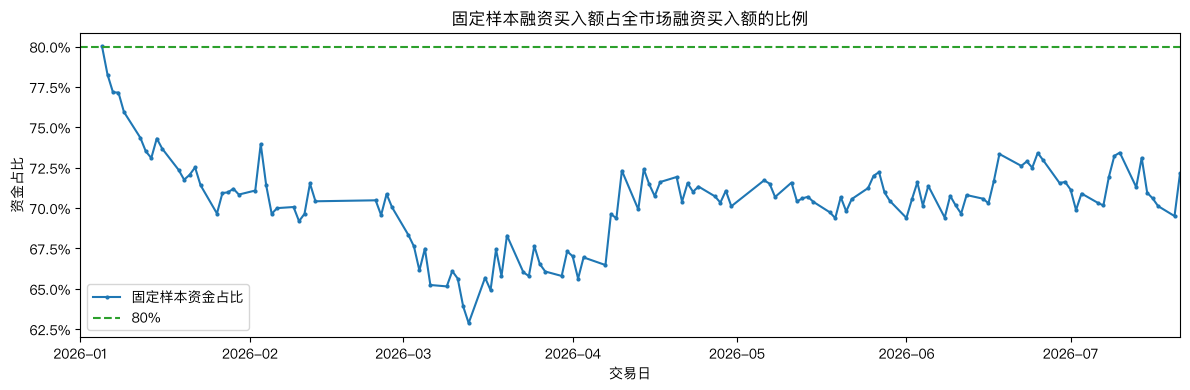

In [4]:
coverage = calculate_sample_coverage(margin, sample)
coverage.to_parquet(DERIVED / 'sample_coverage.parquet', index=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(coverage.trade_date, coverage.sample_coverage, marker='o', markersize=2, label='固定样本资金占比')
ax.axhline(0.8, color='tab:green', ls='--', label='80%')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(pd.Timestamp('2026-01-01'), coverage.trade_date.max())
ax.set_title('固定样本融资买入额占全市场融资买入额的比例')
ax.set_xlabel('交易日')
ax.set_ylabel('资金占比')
ax.legend()
plt.tight_layout()
plt.show()

,样本证券数,有行情证券数,无行情证券数
0,1014,1014,0


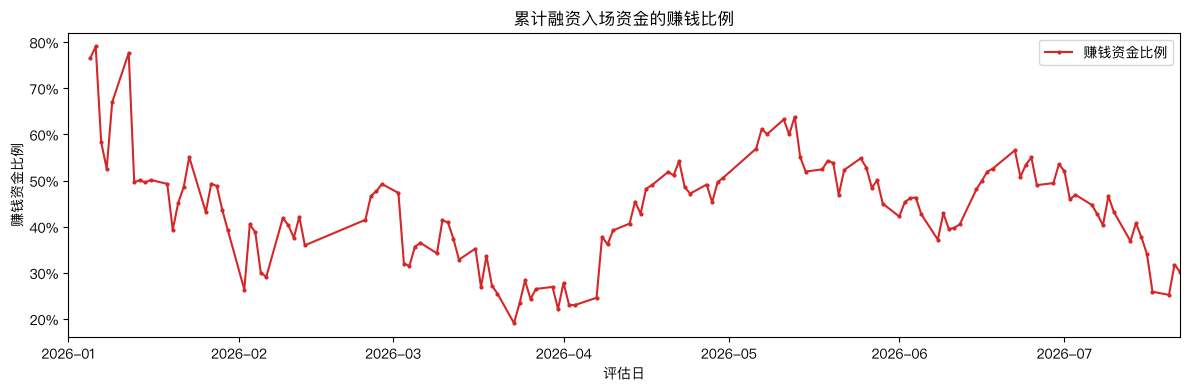

,evaluation_date,cumulative_entry_amount,profitable_amount,profit_ratio,profitable_batch_count,total_batch_count
127,2026-07-16,24406536356715,8318385885329,0.340826,37841,129156
128,2026-07-17,24550916844299,6362056874912,0.259137,29149,130159
129,2026-07-20,24699855692640,6235187538330,0.252438,29738,131162
130,2026-07-21,24892472163405,7916144943639,0.318014,35562,132165
131,2026-07-22,24892472163405,7525100991045,0.302304,34467,132165


In [5]:
sample_keys = sample[['exchange', 'security_code']].drop_duplicates()
positions = build_positions(margin, sample, prices)
missing_price_keys = sample_keys.merge(prices[['exchange', 'security_code']].drop_duplicates(), on=['exchange', 'security_code'], how='left', indicator=True)
missing_price_keys = missing_price_keys.loc[missing_price_keys['_merge'].eq('left_only')].drop(columns='_merge')
display(pd.DataFrame({'样本证券数': [len(sample_keys)], '有行情证券数': [len(sample_keys) - len(missing_price_keys)], '无行情证券数': [len(missing_price_keys)]}))

profitability = calculate_cumulative_profitability(positions, prices)
profitability.to_parquet(DERIVED / 'profit_ratio.parquet', index=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(profitability.evaluation_date, profitability.profit_ratio, color='tab:red', marker='o', markersize=2, label='赚钱资金比例')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(pd.Timestamp('2026-01-01'), profitability.evaluation_date.max())
ax.set_title('累计融资入场资金的赚钱比例')
ax.set_xlabel('评估日')
ax.set_ylabel('赚钱资金比例')
ax.legend()
plt.tight_layout()
plt.show()
profitability.tail()

## 首日融资分层的累计赚钱效应

分层仅由研究起点日（2026-01-05）的全市场融资买入额决定：最高 10 只与排序中位附近连续 10 只。此后成员不变；每个评估日累计该日及以前的有效融资买入批次。行业总体仅统计固定 80% 样本中、与分层证券同业的股票。

,tier,first_day_rank,exchange,security_code,security_name,security_type,industry,industry_classification,financing_buy_amount
0,highest,1,SZSE,300476,胜宏科技,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类,"3,627,252,152"
1,highest,2,SZSE,002050,三花智控,stock,C34通用设备制造业,证监会行业分类,"2,780,581,343"
2,highest,3,SZSE,300308,中际旭创,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类,"2,773,718,089"
3,highest,4,SZSE,300502,新易盛,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类,"2,370,988,542"
4,highest,5,SSE,600118,中国卫星,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类,"2,135,286,965"
5,highest,6,SZSE,300058,蓝色光标,stock,L72商务服务业,证监会行业分类,"2,073,296,785"
6,highest,7,SZSE,300136,信维通信,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类,"1,983,397,856"
7,highest,8,SSE,688981,中芯国际,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类,"1,784,842,495"
8,highest,9,SZSE,300274,阳光电源,stock,C38电气机械和器材制造业,证监会行业分类,"1,684,477,748"
9,highest,10,SZSE,300059,东方财富,stock,J67资本市场服务,证监会行业分类,"1,654,945,507"


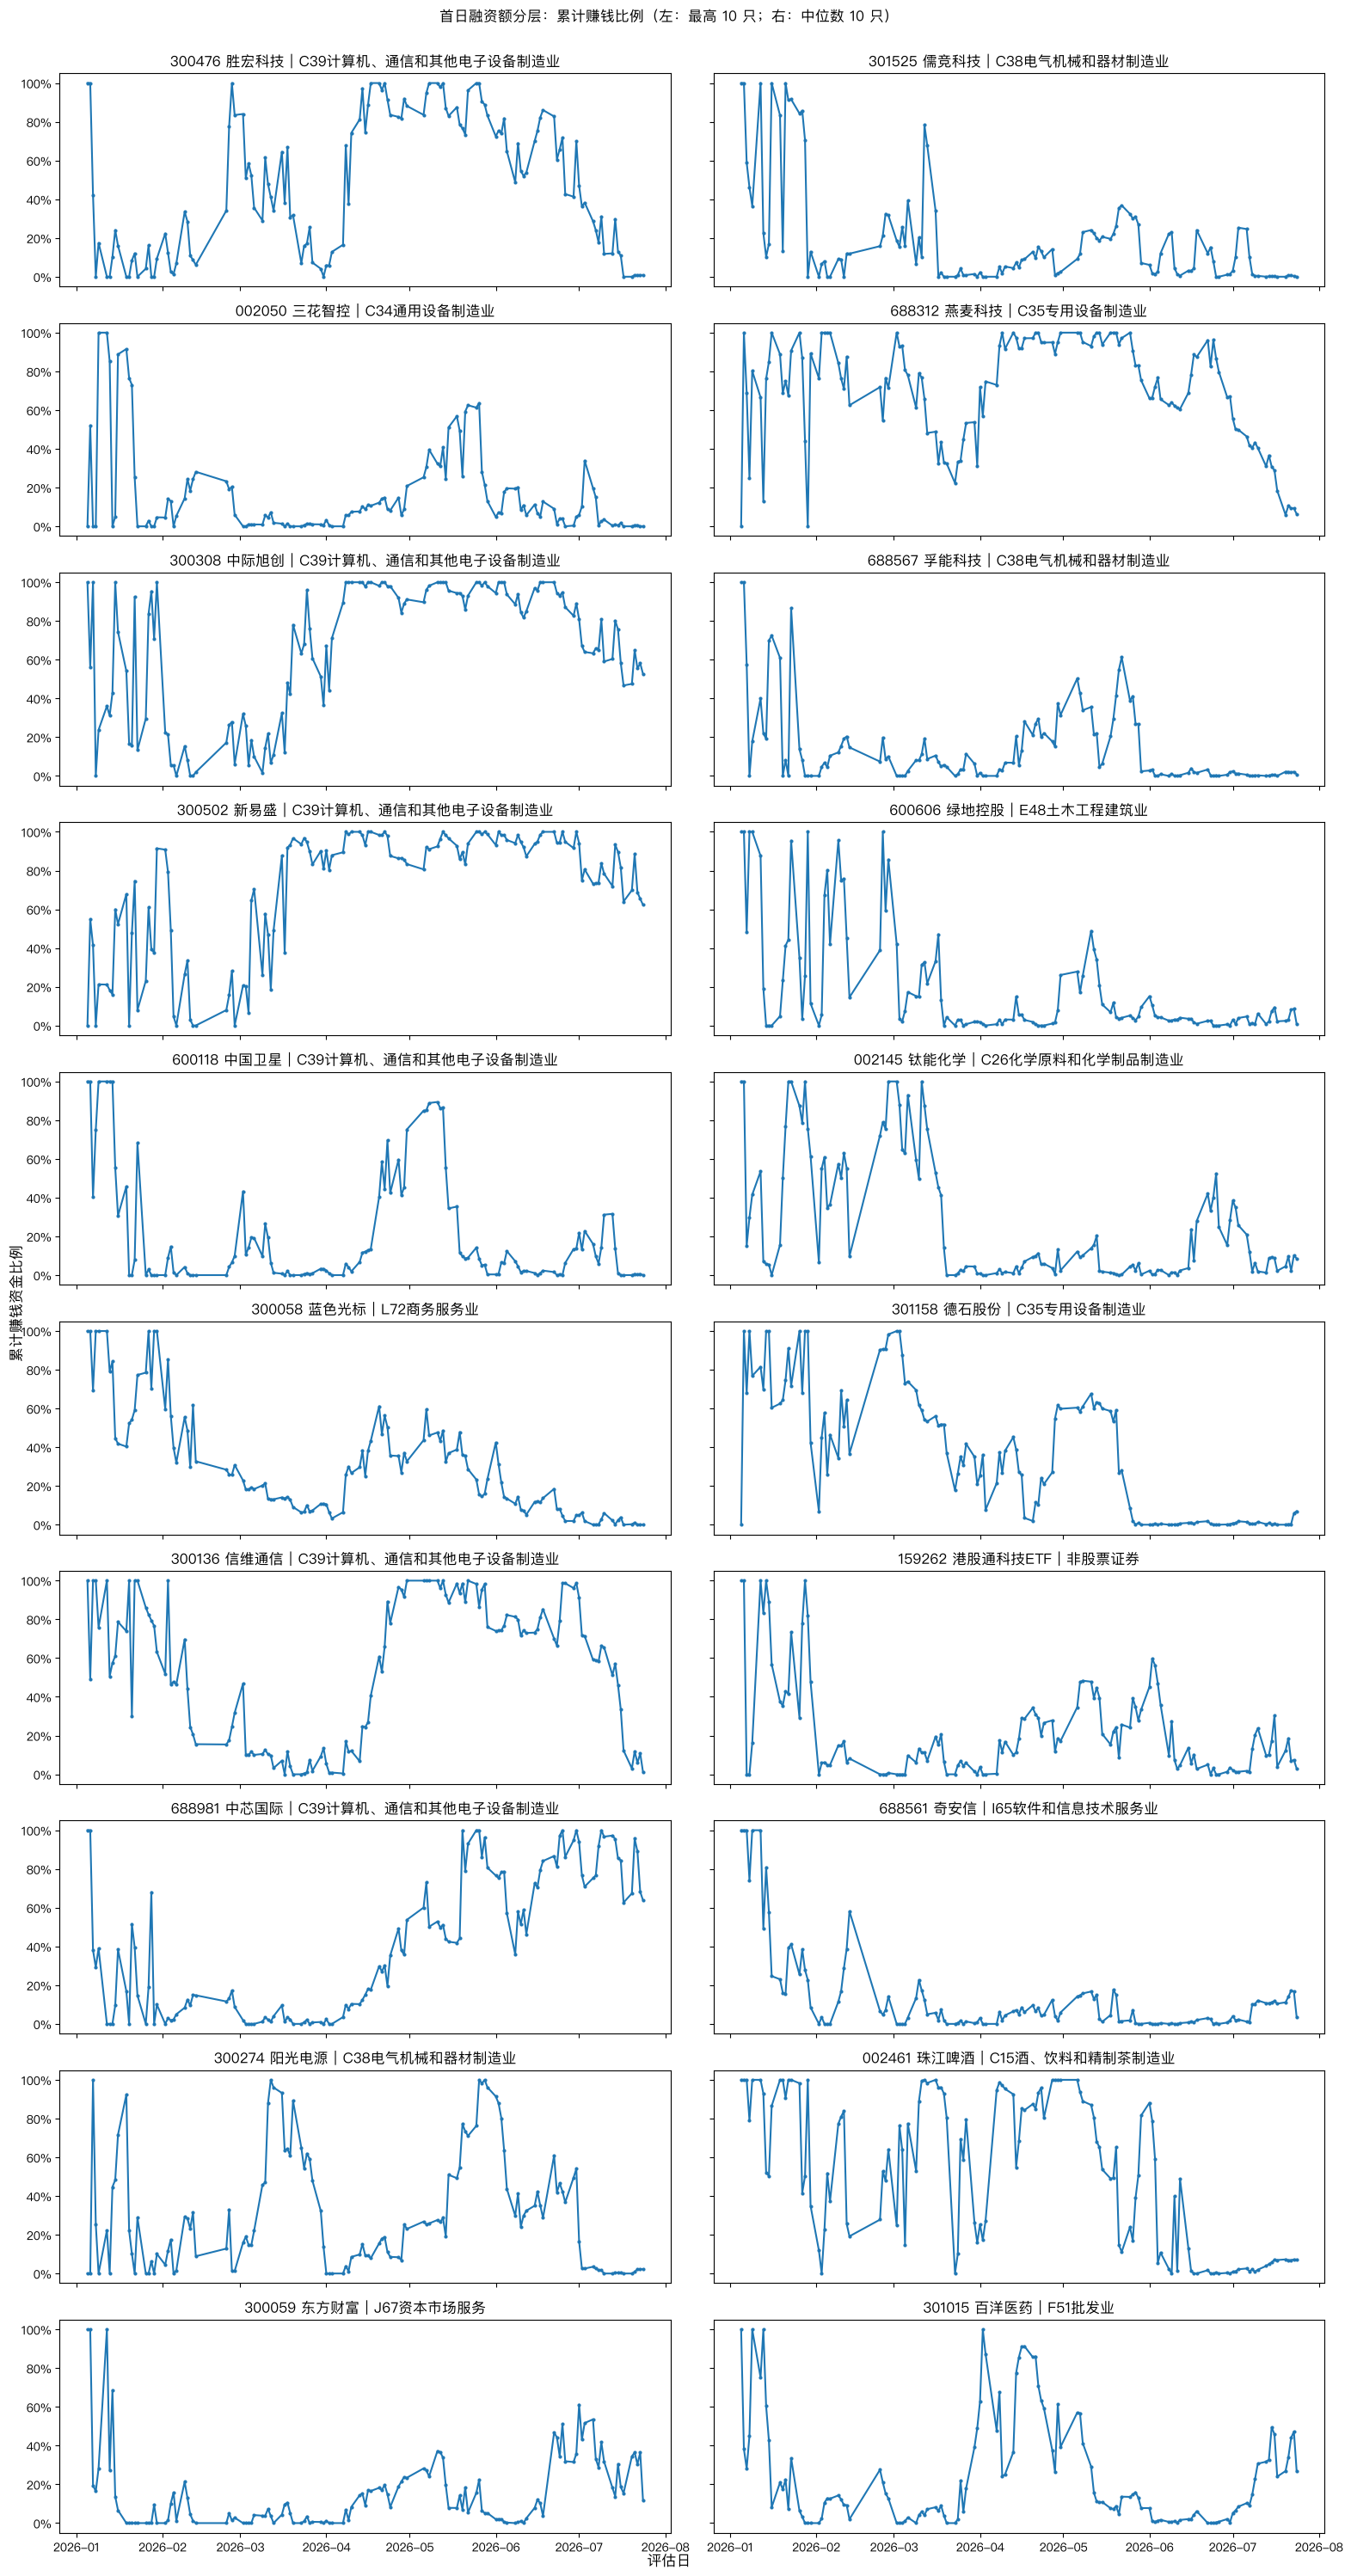

,industry,industry_classification,样本股票数量
0,C15酒、饮料和精制茶制造业,证监会行业分类,3
1,C26化学原料和化学制品制造业,证监会行业分类,39
2,C34通用设备制造业,证监会行业分类,38
3,C35专用设备制造业,证监会行业分类,58
4,C38电气机械和器材制造业,证监会行业分类,61
5,C39计算机、通信和其他电子设备制造业,证监会行业分类,249
6,E48土木工程建筑业,证监会行业分类,6
7,F51批发业,证监会行业分类,9
8,I65软件和信息技术服务业,证监会行业分类,92
9,J67资本市场服务,证监会行业分类,26


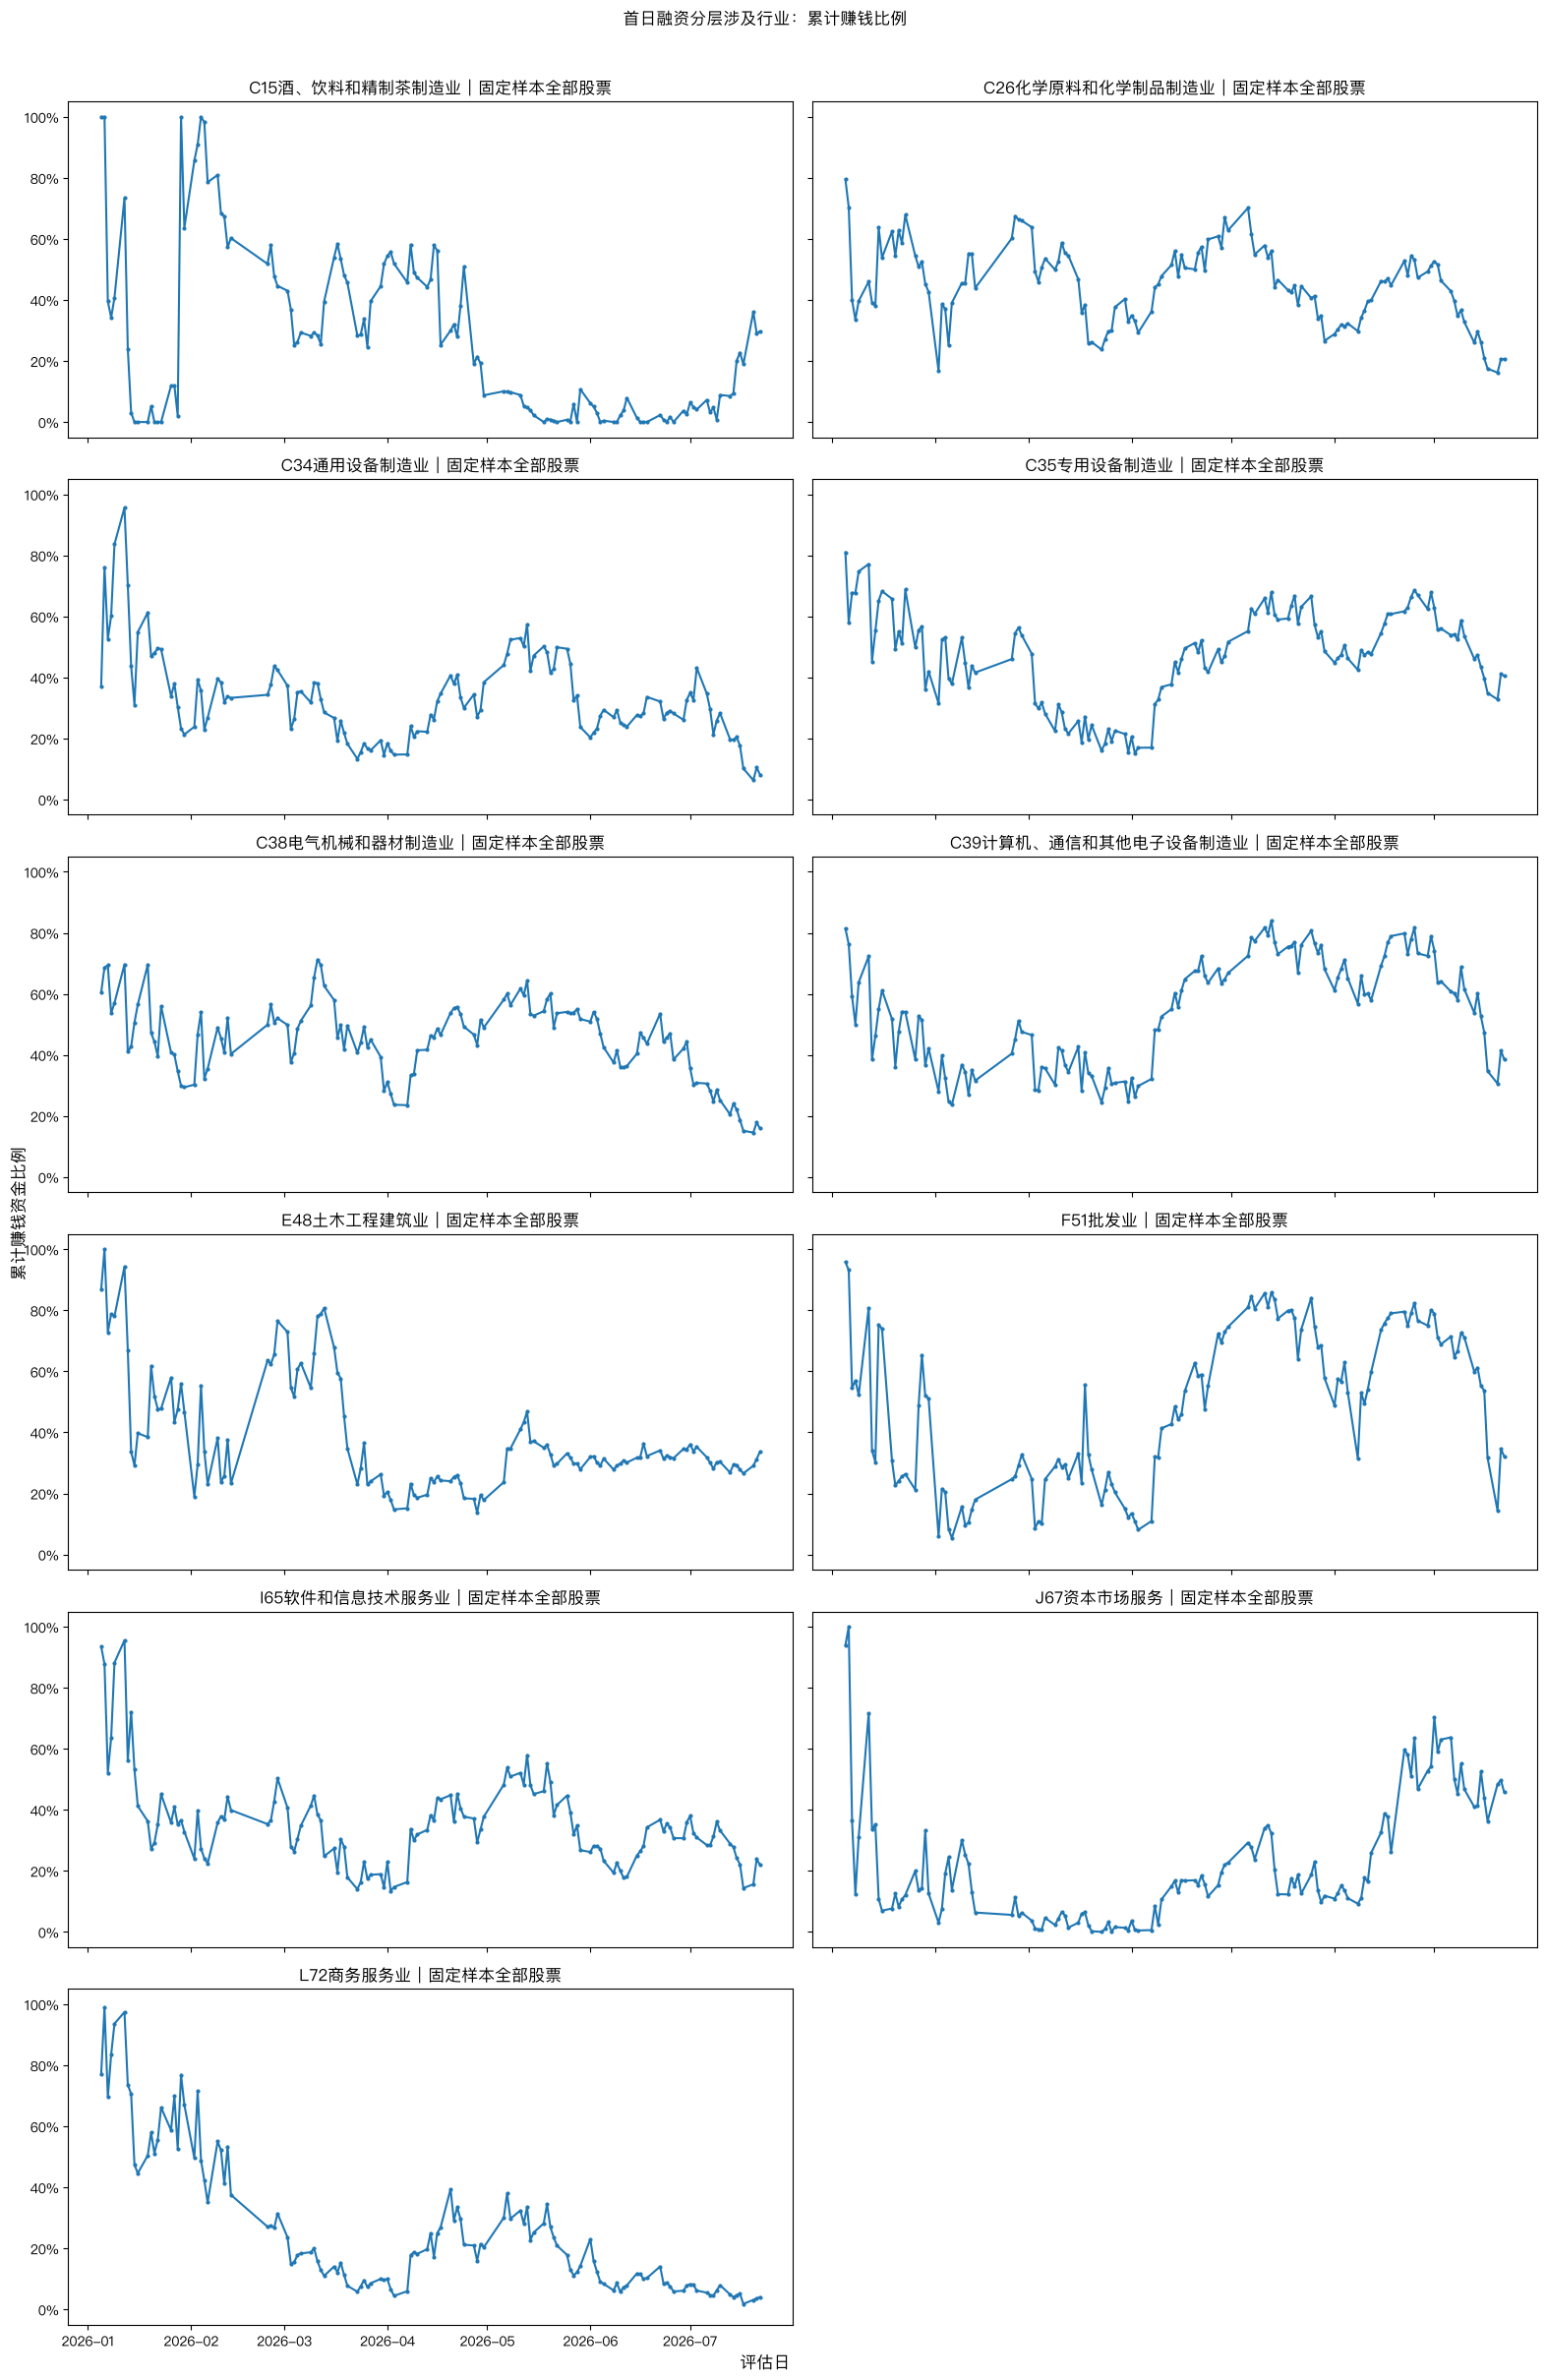

In [6]:
tier_metadata = tiers.merge(
    prepare_security_metadata(tiers, industries, basics),
    on=['exchange', 'security_code'],
    how='left',
    validate='many_to_one',
)
if tier_metadata.security_type.isna().any():
    raise RuntimeError('首日融资分层证券存在未匹配的 BaoStock 基础信息。')

tier_display = tier_metadata[[
    'tier', 'first_day_rank', 'exchange', 'security_code', 'security_name', 'security_type',
    'industry', 'industry_classification', 'financing_buy_amount',
]].sort_values(['tier', 'first_day_rank'])
display(tier_display.style.format({'financing_buy_amount': '{:,.0f}'}))

tier_profitability = calculate_tier_profitability(margin, tiers, tier_prices, tier_metadata)
tier_profitability.to_parquet(DERIVED / 'first_day_financing_tier_profitability.parquet', index=False)

fig, axes = plt.subplots(10, 2, figsize=(16, 30), sharex=True, sharey=True)
for column, tier in enumerate(['highest', 'median']):
    group = tier_metadata.loc[tier_metadata.tier.eq(tier)].sort_values('first_day_rank')
    for axis, security in zip(axes[:, column], group.itertuples(index=False), strict=False):
        series = tier_profitability.loc[
            tier_profitability.tier.eq(tier)
            & tier_profitability.exchange.eq(security.exchange)
            & tier_profitability.security_code.eq(security.security_code)
        ]
        axis.plot(series.evaluation_date, series.cumulative_profit_ratio, marker='o', markersize=2)
        axis.yaxis.set_major_formatter(PercentFormatter(1))
        axis.set_title(f'{security.security_code} {security.security_name}｜{security.industry}')
fig.suptitle('首日融资额分层：累计赚钱比例（左：最高 10 只；右：中位数 10 只）', y=1.002)
fig.supxlabel('评估日')
fig.supylabel('累计赚钱资金比例')
plt.tight_layout()
plt.show()

fixed_industry_metadata = prepare_security_metadata(sample, industries)
tier_industry_profitability, industry_summary = calculate_industry_cumulative_profitability(
    positions, prices, fixed_industry_metadata, tier_metadata
)
tier_industry_profitability.to_parquet(
    DERIVED / 'first_day_financing_tier_industry_profitability.parquet', index=False
)
display(industry_summary)

ncols = 2
nrows = (len(industry_summary) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True, sharey=True)
axes = axes.ravel()
for axis, industry in zip(axes, industry_summary.itertuples(index=False), strict=False):
    series = tier_industry_profitability.loc[
        tier_industry_profitability.industry.eq(industry.industry)
        & tier_industry_profitability.industry_classification.eq(industry.industry_classification)
    ]
    axis.plot(series.evaluation_date, series.cumulative_profit_ratio, marker='o', markersize=2)
    axis.yaxis.set_major_formatter(PercentFormatter(1))
    axis.set_title(f'{industry.industry}｜固定样本全部股票')
for axis in axes[len(industry_summary):]:
    axis.set_visible(False)
fig.suptitle('首日融资分层涉及行业：累计赚钱比例', y=1.01)
fig.supxlabel('评估日')
fig.supylabel('累计赚钱资金比例')
plt.tight_layout()
plt.show()


## 60 日滚动融资赚钱比例

固定首日 80% 样本不变。每个评估日仅统计最近 60 个交易日内的融资买入批次；前 59 个交易日使用已有窗口展示，但不参与证券排名。

In [7]:
WINDOW_DAYS = 60
rolling_security, rolling_overall = calculate_rolling_profitability(positions, prices, WINDOW_DAYS)
rolling_security.to_parquet(DERIVED / 'rolling_profitability.parquet', index=False)
rolling_overall.to_parquet(DERIVED / 'rolling_profitability_overall.parquet', index=False)
rolling_overall.tail()

,evaluation_date,window_start_date,window_trading_days,window_margin_purchase,profitable_amount,rolling_profit_ratio,is_full_window
127,2026-07-16,2026-04-20,60,12747205423320,3849703660948,0.302004,True
128,2026-07-17,2026-04-21,60,12698214012195,2488975700944,0.196010,True
129,2026-07-20,2026-04-22,60,12682383524888,2483051487622,0.195787,True
130,2026-07-21,2026-04-23,60,12687160557772,3650916062508,0.287765,True
131,2026-07-22,2026-04-24,60,12486758192521,3284334969225,0.263025,True


In [8]:
security_metadata = prepare_security_metadata(sample, industries)
HIGH_GROUP_EXCLUDED_CODES = {'511360', '511520'}
selection, profit_ratio_high, profit_ratio_low, return_high, return_low = select_rolling_securities(
    rolling_security, security_metadata, HIGH_GROUP_EXCLUDED_CODES, size=10
)
selection.to_parquet(DERIVED / 'rolling_profitability_selection.parquet', index=False)

selection_columns = ['security_code', 'security_name', 'security_type', 'industry', 'industry_classification', 'mean_profit_ratio', 'mean_weighted_return']
display(pd.concat({'仅赚钱比例高赚钱前 10': profit_ratio_high[selection_columns], '仅赚钱比例低赚钱后 10': profit_ratio_low[selection_columns]}, names=['筛选结果']).style.format({'mean_profit_ratio': '{:.2%}', 'mean_weighted_return': '{:.2%}'}))
display(pd.concat({'加入收益筛选高赚钱前 10': return_high[selection_columns], '加入收益筛选低赚钱后 10': return_low[selection_columns]}, names=['筛选结果']).style.format({'mean_profit_ratio': '{:.2%}', 'mean_weighted_return': '{:.2%}'}))

comparison = compare_rolling_selection(selection, profit_ratio_high, profit_ratio_low, return_high, return_low)
comparison

,分组,状态,exchange,security_code,security_name,security_type,industry,industry_classification
0,high,重合,SSE,688072,拓荆科技,stock,C35专用设备制造业,证监会行业分类
1,high,重合,SSE,688141,杰华特,stock,I65软件和信息技术服务业,证监会行业分类
2,high,重合,SSE,688200,华峰测控,stock,C35专用设备制造业,证监会行业分类
3,high,重合,SSE,688498,源杰科技,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类
4,high,重合,SSE,688630,芯碁微装,stock,C35专用设备制造业,证监会行业分类
5,high,重合,SZSE,002384,东山精密,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类
6,high,重合,SZSE,300502,新易盛,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类
7,high,重合,SZSE,300604,长川科技,stock,C35专用设备制造业,证监会行业分类
8,high,重合,SZSE,300661,圣邦股份,stock,C39计算机、通信和其他电子设备制造业,证监会行业分类
9,high,重合,SZSE,301377,鼎泰高科,stock,C33金属制品业,证监会行业分类


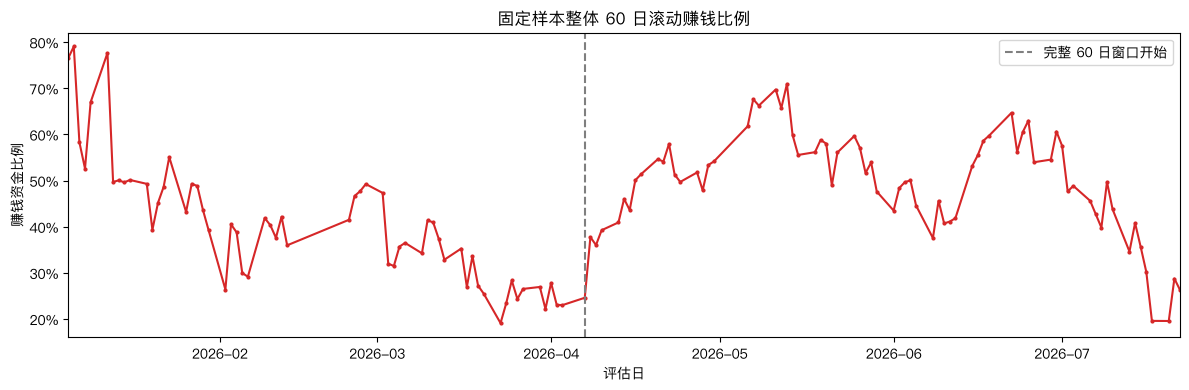

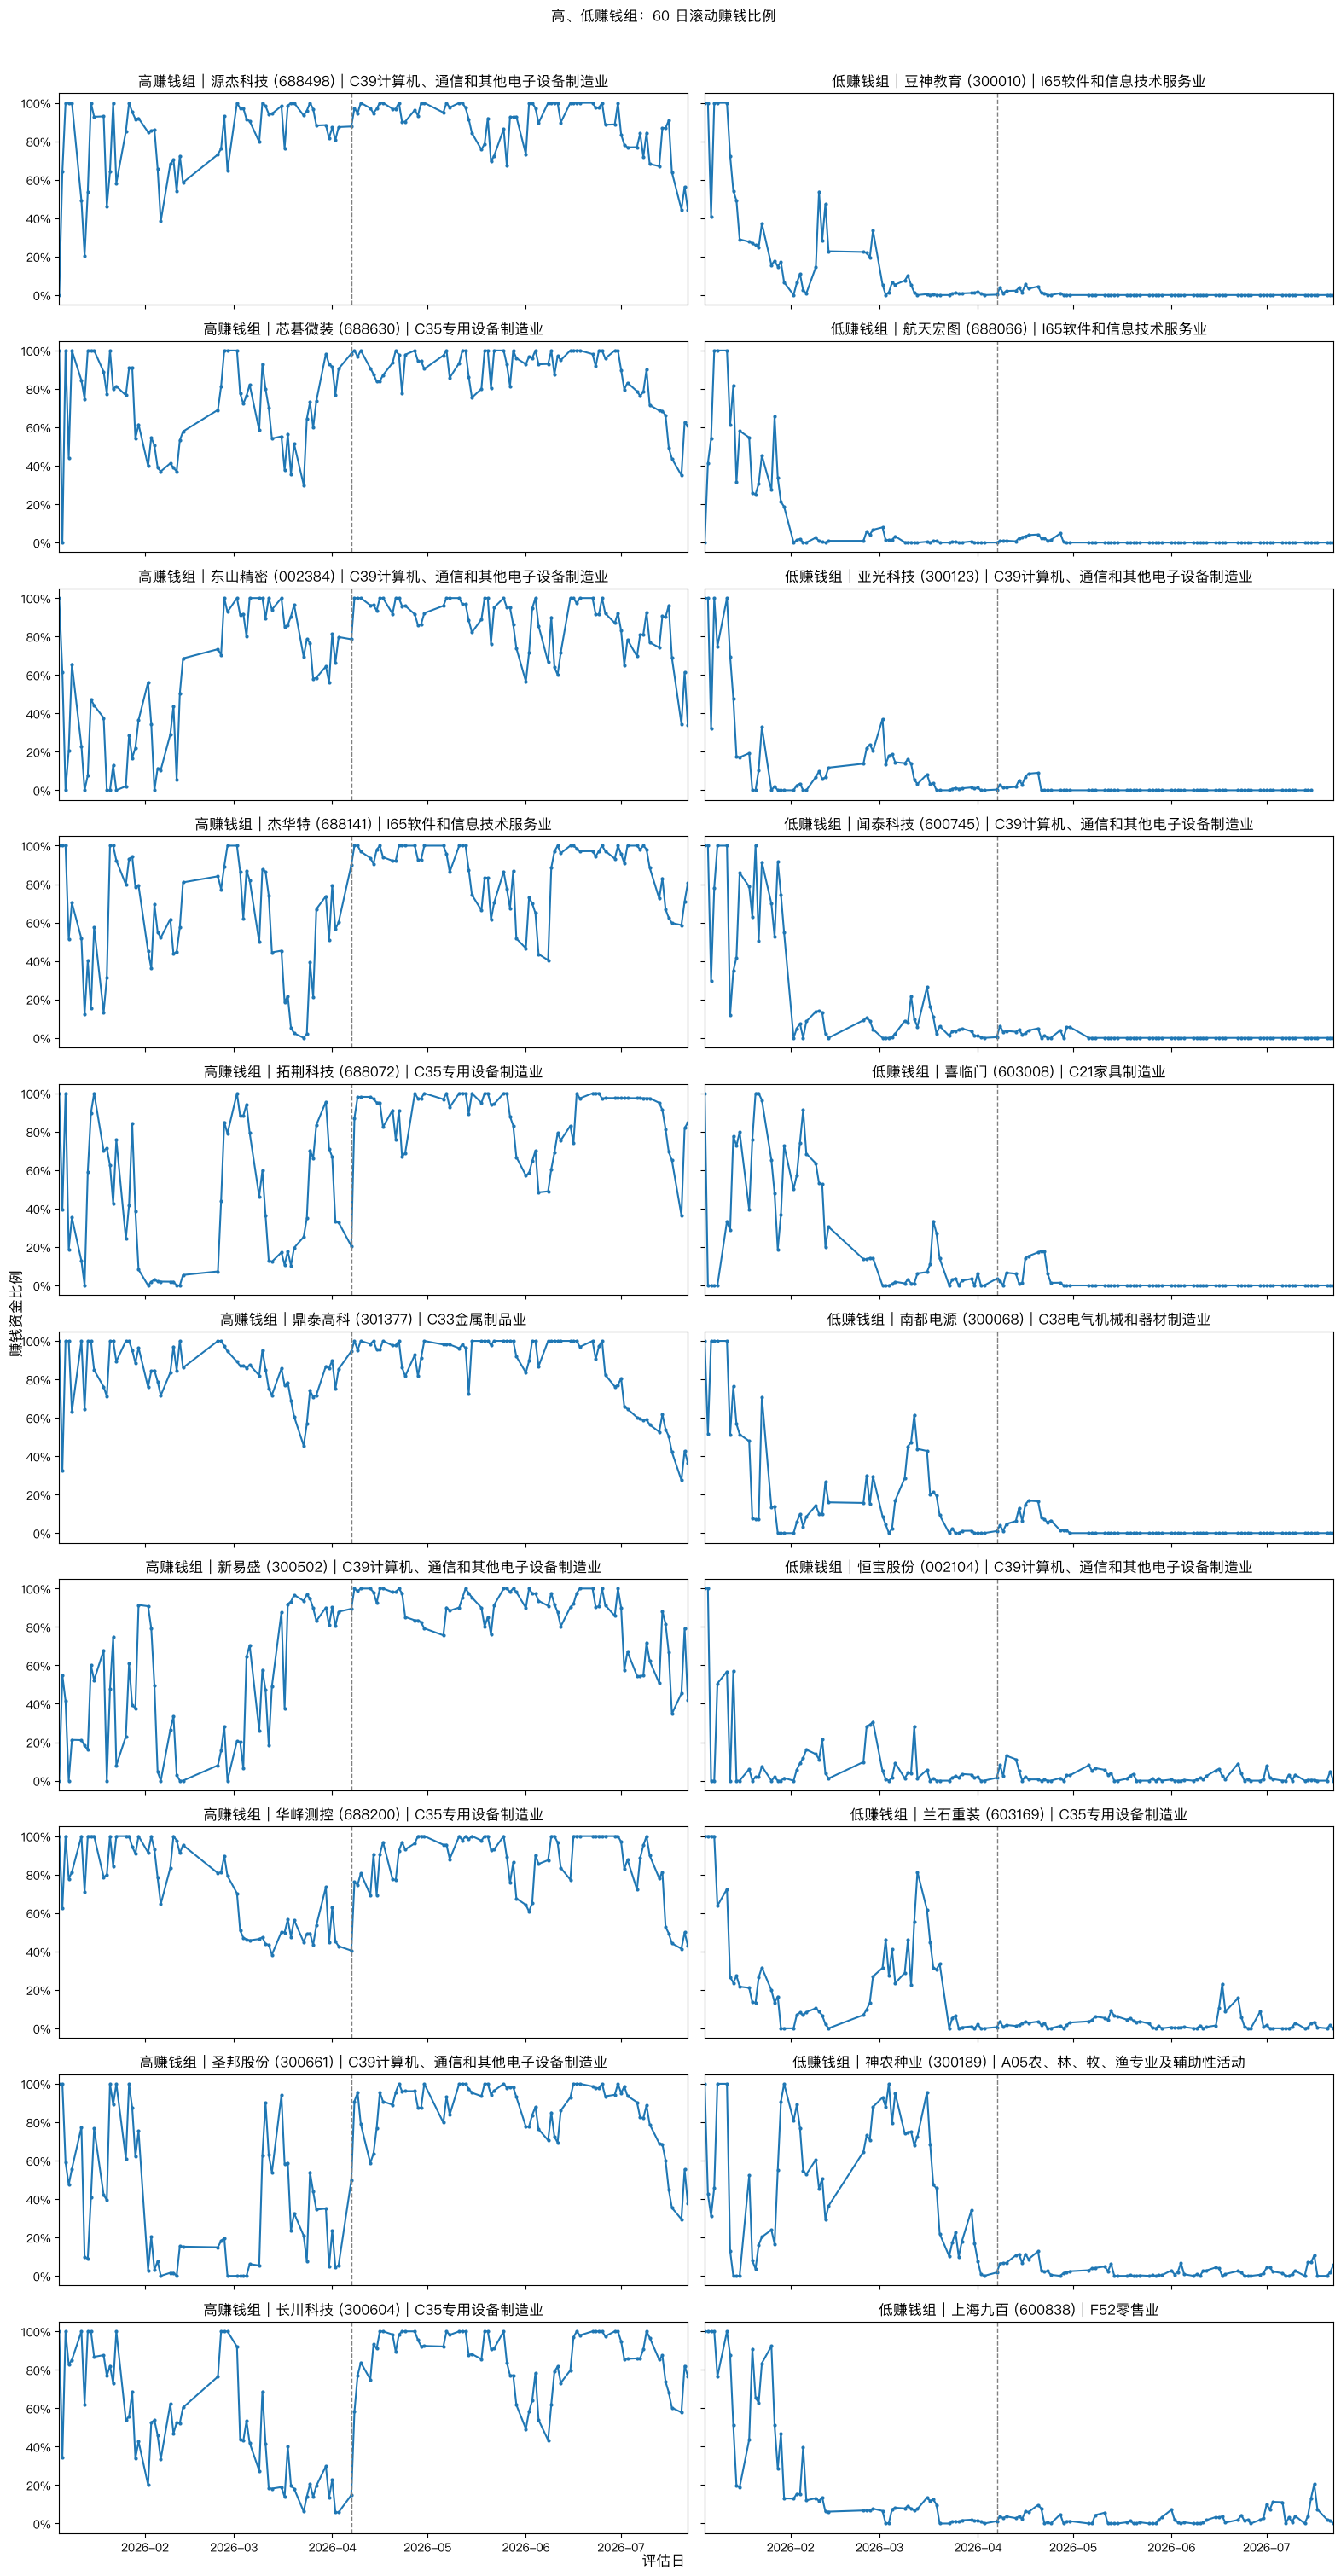

In [9]:
full_window_start = rolling_overall.loc[rolling_overall.is_full_window, 'evaluation_date'].iloc[0]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_overall.evaluation_date, rolling_overall.rolling_profit_ratio, color='tab:red', marker='o', markersize=2)
ax.axvline(full_window_start, color='tab:gray', ls='--', label='完整 60 日窗口开始')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(rolling_overall.evaluation_date.min(), rolling_overall.evaluation_date.max())
ax.set_title('固定样本整体 60 日滚动赚钱比例')
ax.set_xlabel('评估日')
ax.set_ylabel('赚钱资金比例')
ax.legend()
plt.tight_layout()
plt.show()

selected_high = selection.loc[selection.selected_group.eq('high')].nlargest(10, 'mean_profit_ratio').reset_index(drop=True)
selected_low = selection.loc[selection.selected_group.eq('low')].nsmallest(10, 'mean_profit_ratio').reset_index(drop=True)
fig, axes = plt.subplots(10, 2, figsize=(16, 30), sharex=True, sharey=True)
for row_index, (group, title, selected) in enumerate([('high', '高赚钱组', selected_high), ('low', '低赚钱组', selected_low)]):
    for panel_index, security in enumerate(selected.itertuples(index=False)):
        ax = axes[panel_index, row_index]
        series = rolling_security.loc[
            rolling_security.exchange.eq(security.exchange) & rolling_security.security_code.eq(security.security_code)
        ]
        ax.plot(series.evaluation_date, series.rolling_profit_ratio, marker='o', markersize=2)
        ax.axvline(full_window_start, color='tab:gray', ls='--', linewidth=1)
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.set_title(f'{title}｜{security.security_name} ({security.security_code})｜{security.industry}')
        ax.set_xlim(rolling_overall.evaluation_date.min(), rolling_overall.evaluation_date.max())
fig.suptitle('高、低赚钱组：60 日滚动赚钱比例', y=1.01)
fig.supxlabel('评估日')
fig.supylabel('赚钱资金比例')
plt.tight_layout()
plt.show()

## 入选行业的全部股票赚钱效应

以最终高、低组涉及的行业为范围，纳入固定样本中该行业的全部股票；每个行业的赚钱比例按行业内赚钱融资买入资金总额除以行业内融资买入资金总额计算。

,industry,industry_classification,样本股票数量
0,A05农、林、牧、渔专业及辅助性活动,证监会行业分类,1
1,C21家具制造业,证监会行业分类,1
2,C33金属制品业,证监会行业分类,17
3,C35专用设备制造业,证监会行业分类,58
4,C38电气机械和器材制造业,证监会行业分类,61
5,C39计算机、通信和其他电子设备制造业,证监会行业分类,249
6,F52零售业,证监会行业分类,8
7,I65软件和信息技术服务业,证监会行业分类,92


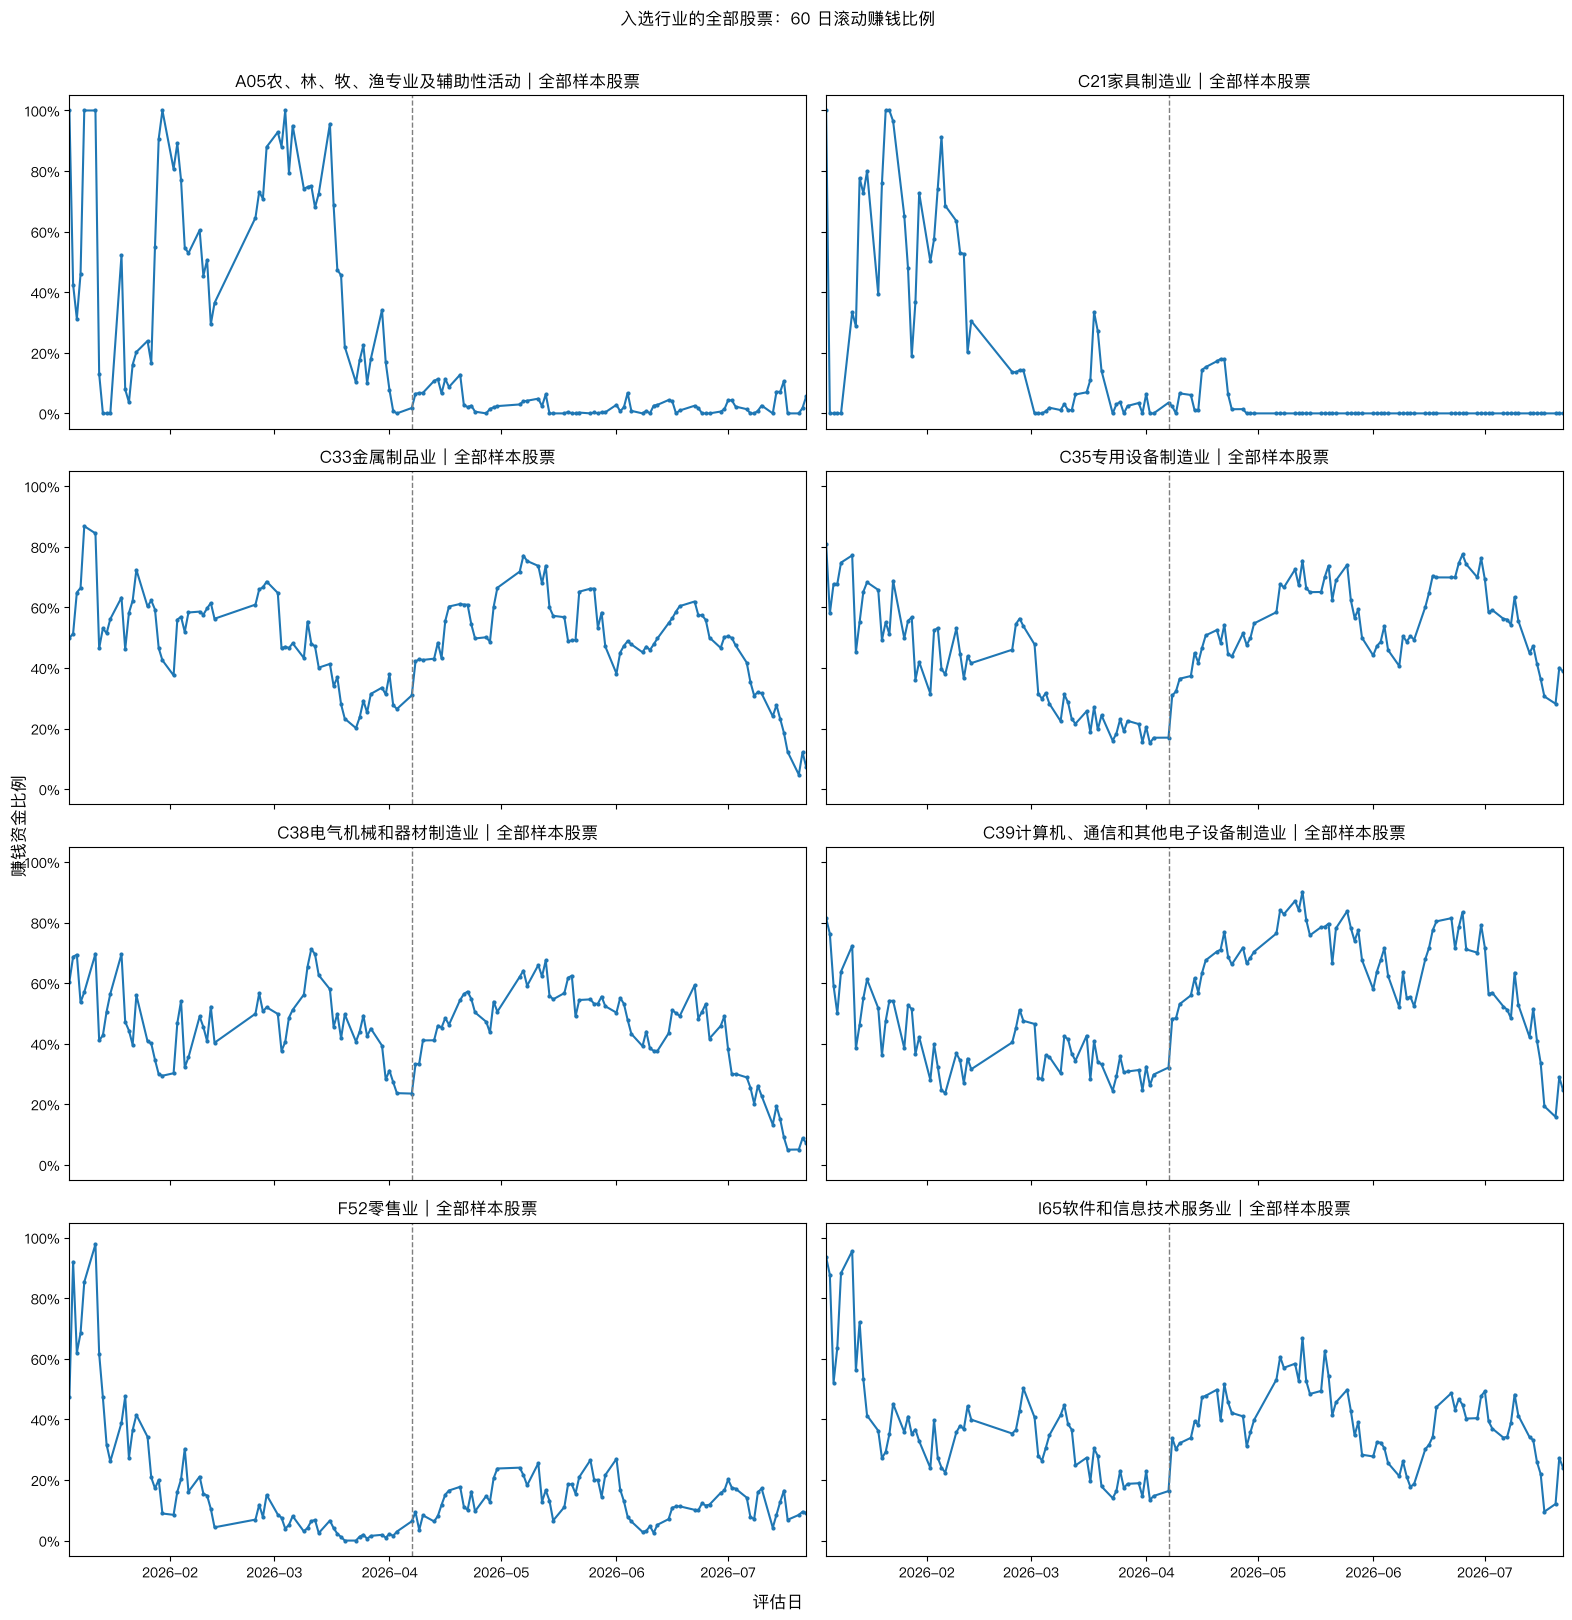

In [10]:
industry_rolling, industry_scope, industry_summary = calculate_rolling_industry_profitability(
    rolling_security, selection, security_metadata
)
industry_rolling.to_parquet(DERIVED / 'rolling_profitability_by_industry.parquet', index=False)
display(industry_summary)

ncols = 2
nrows = (len(industry_scope) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True, sharey=True)
axes = axes.ravel()
for axis, industry in zip(axes, industry_scope.itertuples(index=False), strict=False):
    series = industry_rolling.loc[
        industry_rolling.industry.eq(industry.industry)
        & industry_rolling.industry_classification.eq(industry.industry_classification)
    ]
    axis.plot(series.evaluation_date, series.rolling_profit_ratio, marker='o', markersize=2)
    axis.axvline(full_window_start, color='tab:gray', ls='--', linewidth=1)
    axis.yaxis.set_major_formatter(PercentFormatter(1))
    axis.set_xlim(rolling_overall.evaluation_date.min(), rolling_overall.evaluation_date.max())
    axis.set_title(f'{industry.industry}｜全部样本股票')
for axis in axes[len(industry_scope):]:
    axis.set_visible(False)
fig.suptitle('入选行业的全部股票：60 日滚动赚钱比例', y=1.01)
fig.supxlabel('评估日')
fig.supylabel('赚钱资金比例')
plt.tight_layout()
plt.show()